# Predykcja ceny energii elektrycznej w Hiszpanii
## Analiza i Wizualizacja Danych

**Cel projektu:** Przewidywanie rzeczywistej ceny energii (`price actual`) na hiszpańskim rynku energii
na podstawie danych historycznych o produkcji, zużyciu i warunkach pogodowych.

**Dane:** Godzinowe dane z lat 2015–2018 obejmujące:
- Produkcję energii z różnych źródeł (wiatr, słońce, gaz, atom, węgiel...)
- Zużycie energii (rzeczywiste i prognozowane)
- Ceny energii na rynku dnia następnego i cenę rzeczywistą
- Warunki pogodowe w 5 największych miastach Hiszpanii

**Podejście:**
1. Wczytanie i oczyszczenie danych
2. Inżynieria cech (cechy czasowe, opóźnienia, średnie kroczące)
3. Porównanie trzech modeli: Random Forest, MLP (2 warstwy), MLP (4 warstwy)
4. Ocena za pomocą metryk MAE i RMSE

Źródło danych: [Kaggle – Energy Consumption, Generation, Prices and Weather](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Biblioteki załadowane pomyślnie.")

Biblioteki załadowane pomyślnie.


---
## 1. Wczytanie danych

Wczytujemy dwa pliki CSV:
- `energy_dataset.csv` — dane o produkcji, zużyciu i cenach energii (godzinowe)
- `weather_features.csv` — dane pogodowe z 5 miast Hiszpanii (Valencia, Madryt, Bilbao, Barcelona, Sewilla)

In [25]:
# Wczytanie danych energetycznych
energy_df = pd.read_csv(
    "datasets/energy_dataset.csv",
    parse_dates=["time"],
    index_col="time",
)
energy_df.index = pd.to_datetime(energy_df.index, utc=True)

print(f"Kształt:       {energy_df.shape}")
print(f"Zakres dat:    {energy_df.index.min()} → {energy_df.index.max()}")
print(f"Częstotliwość: godzinowa ({len(energy_df):,} rekordów ≈ {len(energy_df)/8760:.1f} lat)")
energy_df.head(3)

Kształt:       (35064, 28)
Zakres dat:    2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00
Częstotliwość: godzinowa (35,064 rekordów ≈ 4.0 lat)


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48


In [26]:
# Wczytanie danych pogodowych
weather_df = pd.read_csv(
    "datasets/weather_features.csv",
    parse_dates=["dt_iso"],
    index_col="dt_iso",
)
weather_df.index = pd.to_datetime(weather_df.index, utc=True)

print(f"Kształt:    {weather_df.shape}")
print(f"Miasta:     {weather_df['city_name'].str.strip().unique().tolist()}")
print(f"Zakres dat: {weather_df.index.min()} → {weather_df.index.max()}")
weather_df.head(3)

Kształt:    (178396, 16)
Miasta:     ['Valencia', 'Madrid', 'Bilbao', 'Barcelona', 'Seville']
Zakres dat: 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00


,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
dt_iso,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 00:00:00+00:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 01:00:00+00:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


---
## 2. Czyszczenie i przygotowanie danych

### 2.1 Analiza braków w danych energetycznych

In [27]:
# Sprawdzenie brakujących wartości
missing = energy_df.isnull().sum()
missing_pct = (missing / len(energy_df) * 100).round(2)
missing_info = pd.DataFrame({"Brakujące": missing, "Procent [%]": missing_pct})
missing_info = missing_info[missing_info["Brakujące"] > 0].sort_values("Brakujące", ascending=False)

print(f"Kolumny z brakami: {len(missing_info)} / {energy_df.shape[1]}")
missing_info

Kolumny z brakami: 23 / 28


,Brakujące,Procent [%]
generation hydro pumped storage aggregated,35064,100.00
forecast wind offshore eday ahead,35064,100.00
total load actual,36,0.10
generation waste,19,0.05
generation marine,19,0.05
generation hydro pumped storage consumption,19,0.05
generation biomass,19,0.05
generation fossil oil,19,0.05
generation hydro run-of-river and poundage,19,0.05
generation fossil peat,18,0.05


In [28]:
# Usunięcie kolumn, które są w 100% puste (nie wnoszą informacji)
fully_null = [col for col in energy_df.columns if energy_df[col].isnull().all()]
print(f"Kolumny w 100% puste (usuwam): {fully_null}")
energy_df = energy_df.drop(columns=fully_null)

# Uzupełnienie pozostałych braków metodą forward-fill + backward-fill
before = energy_df.isnull().sum().sum()
energy_df = energy_df.ffill().bfill()
after = energy_df.isnull().sum().sum()

print(f"\nBraki przed uzupełnieniem: {before}")
print(f"Braki po uzupełnieniu:     {after}")
print(f"Kształt po czyszczeniu:    {energy_df.shape}")

Kolumny w 100% puste (usuwam): ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']

Braki przed uzupełnieniem: 401
Braki po uzupełnieniu:     0
Kształt po czyszczeniu:    (35064, 26)


### 2.2 Przygotowanie danych pogodowych

Dane pogodowe zawierają odczyty z 5 miast. Obliczamy **średnią krajową** dla każdej godziny
i konwertujemy temperaturę z Kelwinów na stopnie Celsjusza.

In [29]:
# Średnia pogoda z 5 miast (grupowanie po dacie)
weather_numeric = weather_df.select_dtypes(include=[np.number])
weather_avg = weather_numeric.groupby(weather_numeric.index).mean()

# Konwersja Kelwinów → Celsjusze
for col in ["temp", "temp_min", "temp_max"]:
    if col in weather_avg.columns:
        weather_avg[col] = weather_avg[col] - 273.15

# Zmiana nazw kolumn na polskie
weather_avg = weather_avg.rename(columns={
    "temp": "temperatura_sr",
    "humidity": "wilgotnosc",
    "wind_speed": "predkosc_wiatru",
    "pressure": "cisnienie",
    "clouds_all": "zachmurzenie",
    "rain_1h": "opady",
})

# Wybór kolumn pogodowych
weather_cols = [
    "temperatura_sr", "wilgotnosc", "predkosc_wiatru",
    "cisnienie", "zachmurzenie", "opady"
]
weather_avg = weather_avg[weather_cols]

print(f"Średnia pogoda — kształt: {weather_avg.shape}")
print(f"Przykładowa temperatura: {weather_avg['temperatura_sr'].iloc[0]:.1f}°C")
weather_avg.head()

Średnia pogoda — kształt: (35064, 6)
Przykładowa temperatura: -0.7°C


,temperatura_sr,wilgotnosc,predkosc_wiatru,cisnienie,zachmurzenie,opady
dt_iso,,,,,,
2014-12-31 23:00:00+00:00,-0.658537,82.4,2.0,1016.4,0.0,0.0
2015-01-01 00:00:00+00:00,-0.637300,82.4,2.0,1016.2,0.0,0.0
2015-01-01 01:00:00+00:00,-1.050862,82.0,2.4,1016.8,0.0,0.0
2015-01-01 02:00:00+00:00,-1.060531,82.0,2.4,1016.6,0.0,0.0
2015-01-01 03:00:00+00:00,-1.004100,82.0,2.4,1016.6,0.0,0.0


### 2.3 Łączenie danych energetycznych z pogodowymi

In [30]:
# Łączenie po indeksie czasowym (left join)
df = energy_df.join(weather_avg, how="left")

# Uzupełnienie ewentualnych braków w danych pogodowych
df[weather_cols] = df[weather_cols].ffill().bfill()

print(f"Połączony DataFrame: {df.shape}")
print(f"Braki po połączeniu:  {df.isnull().sum().sum()}")
print(f"\nLista kolumn ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Połączony DataFrame: (35064, 32)
Braki po połączeniu:  0

Lista kolumn (32):
   1. generation biomass
   2. generation fossil brown coal/lignite
   3. generation fossil coal-derived gas
   4. generation fossil gas
   5. generation fossil hard coal
   6. generation fossil oil
   7. generation fossil oil shale
   8. generation fossil peat
   9. generation geothermal
  10. generation hydro pumped storage consumption
  11. generation hydro run-of-river and poundage
  12. generation hydro water reservoir
  13. generation marine
  14. generation nuclear
  15. generation other
  16. generation other renewable
  17. generation solar
  18. generation waste
  19. generation wind offshore
  20. generation wind onshore
  21. forecast solar day ahead
  22. forecast wind onshore day ahead
  23. total load forecast
  24. total load actual
  25. price day ahead
  26. price actual
  27. temperatura_sr
  28. wilgotnosc
  29. predkosc_wiatru
  30. cisnienie
  31. zachmurzenie
  32. opady


---
## 3. Inżynieria cech

Tworzymy nowe zmienne, które pomogą modelom lepiej przewidywać cenę energii:

| Typ cechy | Opis | Przykład |
|-----------|------|---------|
| **Cechy czasowe** | Informacje o porze dnia/tygodnia/roku | godzina, dzień tygodnia, miesiąc, weekend |
| **Cechy opóźnione (lags)** | Wartości zmiennej docelowej z przeszłości | cena sprzed 1h, 24h, 7 dni |
| **Średnie kroczące (rolling)** | Średnia z ostatnich N godzin | średnia cena z 24h, średnia temperatura z 24h |

In [31]:
# Zmienna docelowa
TARGET = 'price actual'
if TARGET not in df.columns or df[TARGET].isnull().all():
    TARGET = 'price day ahead'
    print(f"Uwaga: 'price actual' niedostępne — używam '{TARGET}'")
else:
    print(f"Zmienna docelowa: '{TARGET}'")

# === Cechy czasowe ===
df['godzina'] = df.index.hour
df['dzien_tygodnia'] = df.index.dayofweek
df['miesiac'] = df.index.month
df['weekend'] = (df.index.dayofweek >= 5).astype(int)

# === Cechy opóźnione (lags) ===
df['cena_lag_1h'] = df[TARGET].shift(1)        # cena sprzed 1 godziny
df['cena_lag_24h'] = df[TARGET].shift(24)       # cena sprzed 24 godzin
df['cena_lag_168h'] = df[TARGET].shift(168)     # cena sprzed 7 dni (168h)

# === Średnie kroczące ===
df['cena_rolling_24h'] = df[TARGET].rolling(window=24).mean()
df['temp_rolling_24h'] = df['temperatura_sr'].rolling(window=24).mean()

print("\nNowe cechy dodane:")
new_cols = ['godzina', 'dzien_tygodnia', 'miesiac', 'weekend',
            'cena_lag_1h', 'cena_lag_24h', 'cena_lag_168h',
            'cena_rolling_24h', 'temp_rolling_24h']
for col in new_cols:
    print(f"  • {col}")

Zmienna docelowa: 'price actual'

Nowe cechy dodane:
  • godzina
  • dzien_tygodnia
  • miesiac
  • weekend
  • cena_lag_1h
  • cena_lag_24h
  • cena_lag_168h
  • cena_rolling_24h
  • temp_rolling_24h


In [32]:
# Usunięcie wierszy z NaN (powstałych z lags i rolling)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f"Usunięto {rows_before - rows_after} wierszy z NaN (z powodu lags/rolling)")
print(f"Kształt końcowy: {df.shape}")
print(f"Zakres dat:      {df.index.min()} → {df.index.max()}")

Usunięto 168 wierszy z NaN (z powodu lags/rolling)
Kształt końcowy: (34896, 41)
Zakres dat:      2015-01-07 23:00:00+00:00 → 2018-12-31 22:00:00+00:00


### 3.1 Eksploracja danych po inżynierii cech

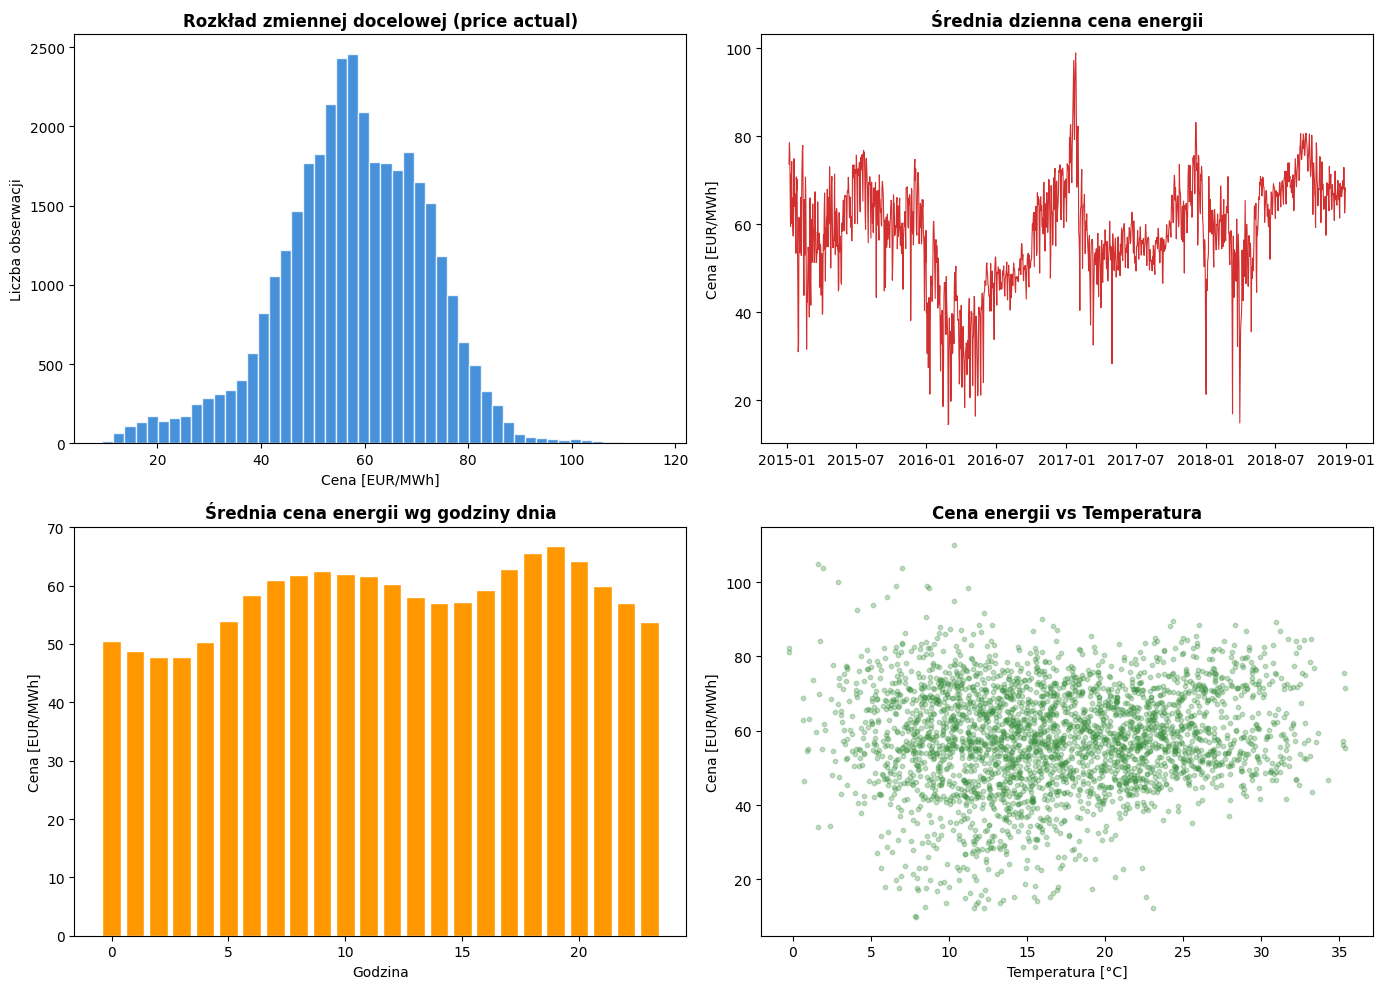

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rozkład zmiennej docelowej
axes[0, 0].hist(df[TARGET], bins=50, color='#1976D2', edgecolor='white', alpha=0.8)
axes[0, 0].set_title(f'Rozkład zmiennej docelowej ({TARGET})', fontweight='bold')
axes[0, 0].set_xlabel('Cena [EUR/MWh]')
axes[0, 0].set_ylabel('Liczba obserwacji')

# Cena w czasie (średnia dzienna)
daily_price = df[TARGET].resample('D').mean()
axes[0, 1].plot(daily_price, linewidth=0.8, color='#D32F2F')
axes[0, 1].set_title('Średnia dzienna cena energii', fontweight='bold')
axes[0, 1].set_ylabel('Cena [EUR/MWh]')

# Cena wg godziny dnia
hourly_avg = df.groupby('godzina')[TARGET].mean()
axes[1, 0].bar(hourly_avg.index, hourly_avg.values, color='#FF9800', edgecolor='white')
axes[1, 0].set_title('Średnia cena energii wg godziny dnia', fontweight='bold')
axes[1, 0].set_xlabel('Godzina')
axes[1, 0].set_ylabel('Cena [EUR/MWh]')

# Cena vs temperatura
sample = df.sample(min(3000, len(df)), random_state=42)
axes[1, 1].scatter(sample['temperatura_sr'], sample[TARGET],
                   alpha=0.3, s=10, color='#388E3C')
axes[1, 1].set_title('Cena energii vs Temperatura', fontweight='bold')
axes[1, 1].set_xlabel('Temperatura [°C]')
axes[1, 1].set_ylabel('Cena [EUR/MWh]')

plt.tight_layout()
plt.show()

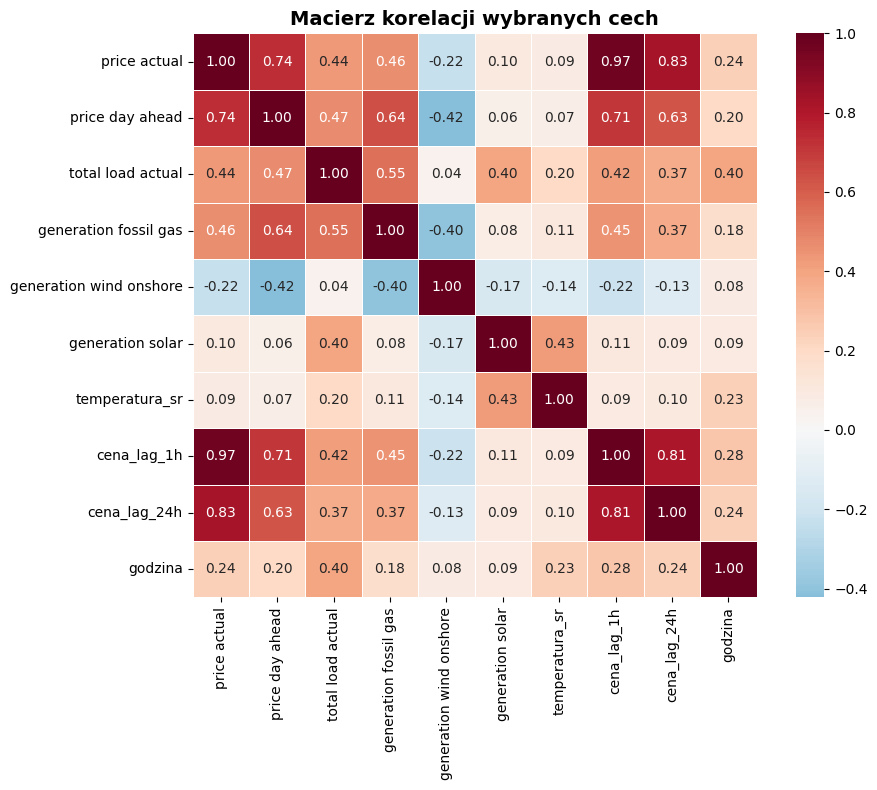

In [34]:
# Macierz korelacji wybranych cech z ceną
corr_cols = [TARGET, 'price day ahead', 'total load actual',
             'generation fossil gas', 'generation wind onshore',
             'generation solar', 'temperatura_sr',
             'cena_lag_1h', 'cena_lag_24h', 'godzina']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Macierz korelacji wybranych cech', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Podział danych i skalowanie

Dzielimy dane **chronologicznie** (80% trening, 20% test). Dane z przyszlości nie mogą wyciekać do zbioru treningowego

Następnie skalujemy cechy za pomocą `StandardScaler`.

In [35]:
# Wybór cech do modelu
FEATURES = [
    # Dane rynkowe
    'price day ahead',
    'total load forecast',
    'total load actual',
    # Produkcja energii (wybrane źródła)
    'generation fossil gas',
    'generation nuclear',
    'generation wind onshore',
    'generation solar',
    # Prognozy produkcji
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
    # Pogoda
    'temperatura_sr',
    'wilgotnosc',
    'predkosc_wiatru',
    # Cechy czasowe
    'godzina',
    'dzien_tygodnia',
    'miesiac',
    'weekend',
    # Cechy opóźnione i średnie kroczące
    'cena_lag_1h',
    'cena_lag_24h',
    'cena_lag_168h',
    'cena_rolling_24h',
    'temp_rolling_24h',
]

# Bezpieczeństwo — bierzemy tylko cechy, które istnieją w DataFrame
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Liczba wybranych cech: {len(FEATURES)}")
for f in FEATURES:
    print(f"  • {f}")

Liczba wybranych cech: 21
  • price day ahead
  • total load forecast
  • total load actual
  • generation fossil gas
  • generation nuclear
  • generation wind onshore
  • generation solar
  • forecast solar day ahead
  • forecast wind onshore day ahead
  • temperatura_sr
  • wilgotnosc
  • predkosc_wiatru
  • godzina
  • dzien_tygodnia
  • miesiac
  • weekend
  • cena_lag_1h
  • cena_lag_24h
  • cena_lag_168h
  • cena_rolling_24h
  • temp_rolling_24h


In [36]:
X = df[FEATURES]
y = df[TARGET]

# Podział chronologiczny: 80% trening, 20% test
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Zbiór treningowy: {X_train.shape[0]:,} próbek")
print(f"  Zakres: {X_train.index.min().date()} → {X_train.index.max().date()}")
print(f"\nZbiór testowy:    {X_test.shape[0]:,} próbek")
print(f"  Zakres: {X_test.index.min().date()} → {X_test.index.max().date()}")

# Skalowanie cech (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nSkalowanie wykonane (StandardScaler).")

Zbiór treningowy: 27,916 próbek
  Zakres: 2015-01-07 → 2018-03-16

Zbiór testowy:    6,980 próbek
  Zakres: 2018-03-16 → 2018-12-31

Skalowanie wykonane (StandardScaler).


---
## 5. Model 1 — Random Forest Regressor (Baseline)

Random Forest to **zespół drzew decyzyjnych** — prosty, ale bardzo skuteczny model.
Używamy go jako *baseline* do porównania z sieciami neuronowymi.

Zalety:
- Nie wymaga specjalnego skalowania danych
- Odporny na outliersy
- Pozwala łatwo interpretować ważność cech

In [37]:
# Trenowanie modelu Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)

# Predykcja na zbiorze testowym
y_pred_rf = rf_model.predict(X_test_scaled)

# Obliczenie metryk
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest — wyniki na zbiorze testowym:")
print(f"  MAE:  {mae_rf:.2f} EUR/MWh")
print(f"  RMSE: {rmse_rf:.2f} EUR/MWh")

Random Forest — wyniki na zbiorze testowym:
  MAE:  1.70 EUR/MWh
  RMSE: 2.32 EUR/MWh


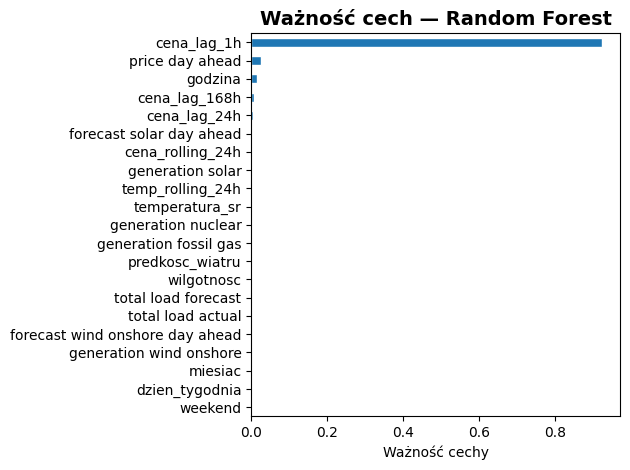

In [48]:
# Ważność cech w modelu Random Forest
importance = pd.Series(rf_model.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=True)

plt.figure()
importance.plot(kind='barh', edgecolor='white')
plt.title('Ważność cech — Random Forest', fontweight='bold', fontsize=14)
plt.xlabel('Ważność cechy')
plt.tight_layout()
plt.show()

---
## 6. Modele sieci neuronowych MLP (Keras/TensorFlow)

**MLP (Multi-Layer Perceptron)** to podstawowy typ sieci neuronowej ze sprzężeniem w przód.

Porównujemy dwa warianty różniące się głębokością architektury:

| | Wariant A | Wariant B |
|---|---|---|
| **Warstwy ukryte** | 2 | 4 |
| **Neurony** | 64 → 32 | 128 → 64 → 32 → 16 |
| **Dropout** | 0.2 | 0.3 / 0.2 |

Oba modele używają:
- Funkcji aktywacji **ReLU**
- Warstw **Dropout** (zapobieganie przeuczeniu)
- Optymalizatora **Adam**
- **Early Stopping** (automatyczne zatrzymanie treningu)

### 6.1 Wariant A — MLP z 2 warstwami ukrytymi (64, 32 neurony)

In [39]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

# Budowa modelu — Wariant A (prostsza architektura)
model_a = keras.Sequential([
    keras.layers.Dense(64, activation='relu',
                       input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1),
])

model_a.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Architektura modelu A (2 warstwy ukryte):")
model_a.summary()

Architektura modelu A (2 warstwy ukryte):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Trenowanie modelu A
early_stop_a = keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor='val_loss',
)

history_a = model_a.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_a],
    verbose=1,
)

# Predykcja na zbiorze testowym
y_pred_mlp_a = model_a.predict(X_test_scaled).flatten()

# Metryki
mae_mlp_a = mean_absolute_error(y_test, y_pred_mlp_a)
rmse_mlp_a = np.sqrt(mean_squared_error(y_test, y_pred_mlp_a))

print(f"\nMLP Wariant A (2 warstwy) — wyniki na zbiorze testowym:")
print(f"  MAE:  {mae_mlp_a:.2f} EUR/MWh")
print(f"  RMSE: {rmse_mlp_a:.2f} EUR/MWh")

Epoch 1/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1092.5229 - mae: 26.1330 - val_loss: 94.3412 - val_mae: 7.8046
Epoch 2/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 158.3321 - mae: 10.0141 - val_loss: 53.2364 - val_mae: 5.7296
Epoch 3/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 124.3221 - mae: 8.8760 - val_loss: 42.2776 - val_mae: 5.0989
Epoch 4/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - loss: 109.5246 - mae: 8.2723 - val_loss: 35.9402 - val_mae: 4.7215
Epoch 5/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 101.0392 - mae: 7.8934 - val_loss: 29.4776 - val_mae: 4.2166
Epoch 6/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 96.9987 - mae: 7.7295 - val_loss: 23.9830 - val_mae: 3.7309
Epoch 7/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 88.6231 - mae: 7.3846 - val_loss: 20.6354 - val_mae: 3.3469
Epoch 8/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 87.0770 - mae: 7.3237 - val_loss: 18.2070 - val_mae: 3.1250
Epoch 9/100
349/349 

### 6.2 Wariant B — MLP z 4 warstwami ukrytymi (128, 64, 32, 16 neuronów)

In [41]:
tf.random.set_seed(42)

# Budowa modelu — Wariant B (głębsza architektura)
model_b = keras.Sequential([
    keras.layers.Dense(128, activation='relu',
                       input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1),
])

model_b.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Architektura modelu B (4 warstwy ukryte):")
model_b.summary()

Architektura modelu B (4 warstwy ukryte):


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,697 (53.50 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Trenowanie modelu B
early_stop_b = keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor='val_loss',
)

history_b = model_b.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_b],
    verbose=1,
)

# Predykcja na zbiorze testowym
y_pred_mlp_b = model_b.predict(X_test_scaled).flatten()

# Metryki
mae_mlp_b = mean_absolute_error(y_test, y_pred_mlp_b)
rmse_mlp_b = np.sqrt(mean_squared_error(y_test, y_pred_mlp_b))

print(f"\nMLP Wariant B (4 warstwy) — wyniki na zbiorze testowym:")
print(f"  MAE:  {mae_mlp_b:.2f} EUR/MWh")
print(f"  RMSE: {rmse_mlp_b:.2f} EUR/MWh")

Epoch 1/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 564.6343 - mae: 16.7554 - val_loss: 51.4759 - val_mae: 5.6665
Epoch 2/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - loss: 107.8891 - mae: 8.1863 - val_loss: 57.0520 - val_mae: 6.3620
Epoch 3/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - loss: 79.3456 - mae: 7.0061 - val_loss: 90.7816 - val_mae: 8.6742
Epoch 4/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - loss: 67.0423 - mae: 6.4315 - val_loss: 115.9625 - val_mae: 10.0189
Epoch 5/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - loss: 57.2082 - mae: 5.8957 - val_loss: 114.3254 - val_mae: 9.9664
Epoch 6/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - loss: 49.4309 - mae: 5.4790 - val_loss: 147.9959 - val_mae: 11.4772
Epoch 7/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 42.9829 - mae: 5.0685 - val_loss: 157.2452 - val_mae: 11.8244
Epoch 8/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - loss: 38.9717 - mae: 4.8140 - val_loss: 169.9597 - val_mae: 12.3180
Epoch 

### 6.3 Porównanie krzywych uczenia (loss curves)

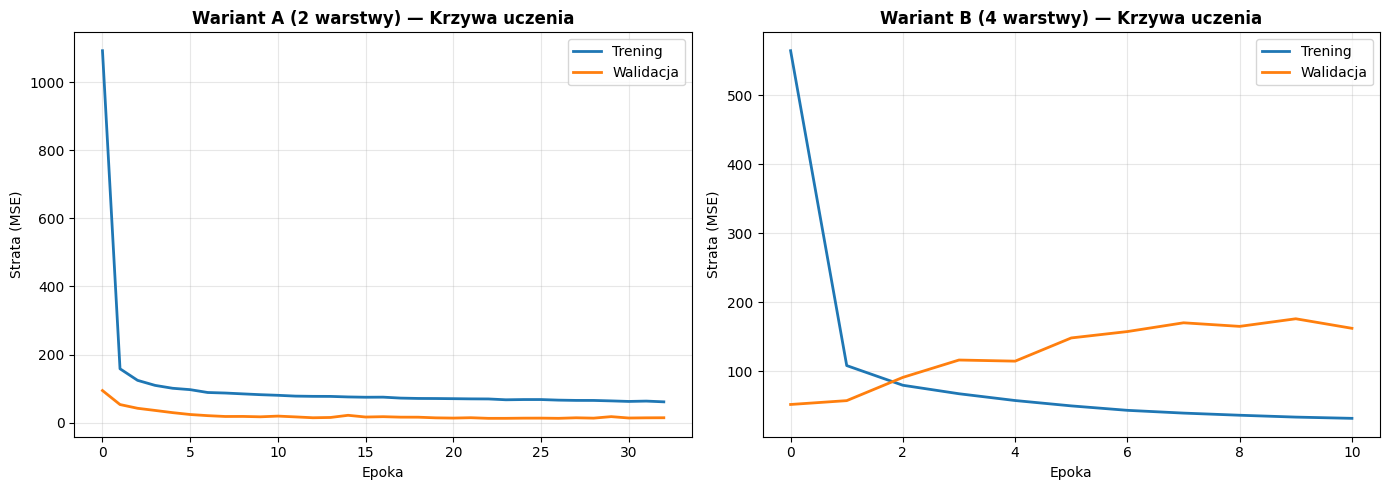

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wariant A
axes[0].plot(history_a.history['loss'], label='Trening', linewidth=2)
axes[0].plot(history_a.history['val_loss'], label='Walidacja', linewidth=2)
axes[0].set_title('Wariant A (2 warstwy) — Krzywa uczenia', fontweight='bold')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Strata (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Wariant B
axes[1].plot(history_b.history['loss'], label='Trening', linewidth=2)
axes[1].plot(history_b.history['val_loss'], label='Walidacja', linewidth=2)
axes[1].set_title('Wariant B (4 warstwy) — Krzywa uczenia', fontweight='bold')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Strata (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Porównanie modeli

### 7.1 Tabela zbiorcza wyników

In [44]:
# Tabela zbiorcza wyników
results = pd.DataFrame({
    'Model': ['Random Forest', 'MLP — 2 warstwy (A)', 'MLP — 4 warstwy (B)'],
    'MAE [EUR/MWh]': [mae_rf, mae_mlp_a, mae_mlp_b],
    'RMSE [EUR/MWh]': [rmse_rf, rmse_mlp_a, rmse_mlp_b],
})

best_mae_idx = results['MAE [EUR/MWh]'].idxmin()
best_rmse_idx = results['RMSE [EUR/MWh]'].idxmin()

print("=" * 60)
print("         PORÓWNANIE MODELI — TABELA WYNIKÓW")
print("=" * 60)
print(results.to_string(index=False))
print()
print(f"Najlepszy MAE:  {results.loc[best_mae_idx, 'Model']}"
      f" ({results.loc[best_mae_idx, 'MAE [EUR/MWh]']:.2f})")
print(f"Najlepszy RMSE: {results.loc[best_rmse_idx, 'Model']}"
      f" ({results.loc[best_rmse_idx, 'RMSE [EUR/MWh]']:.2f})")

         PORÓWNANIE MODELI — TABELA WYNIKÓW
              Model  MAE [EUR/MWh]  RMSE [EUR/MWh]
      Random Forest       1.703228        2.321401
MLP — 2 warstwy (A)       2.048938        2.798223
MLP — 4 warstwy (B)       5.262017        6.532576

Najlepszy MAE:  Random Forest (1.70)
Najlepszy RMSE: Random Forest (2.32)


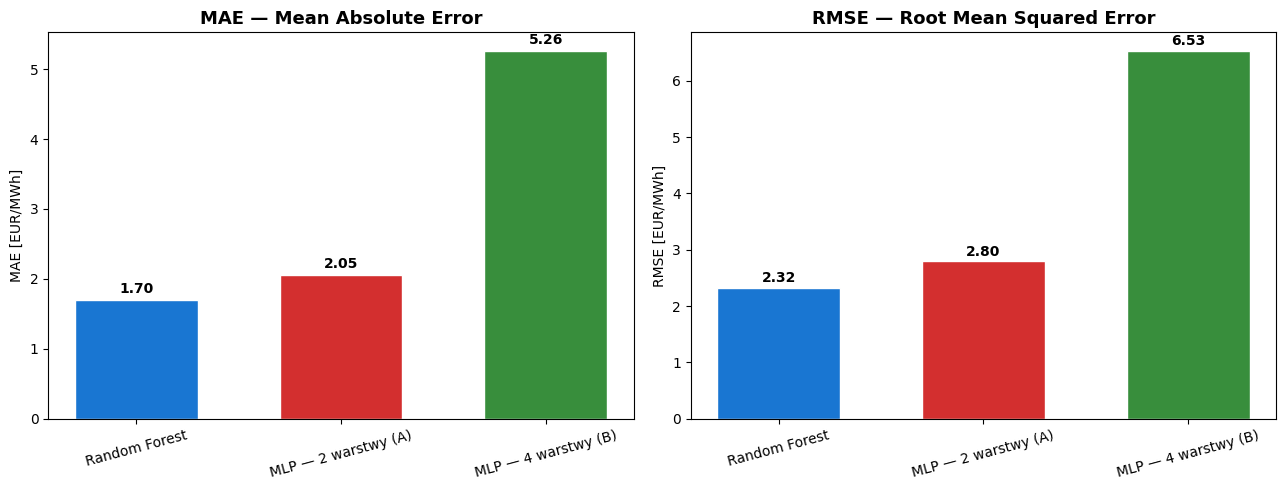

In [45]:
# Wykres porównawczy MAE i RMSE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#1976D2', '#D32F2F', '#388E3C']

# MAE
bars_mae = axes[0].bar(results['Model'], results['MAE [EUR/MWh]'],
                       color=colors, edgecolor='white', width=0.6)
axes[0].set_title('MAE — Mean Absolute Error', fontweight='bold', fontsize=13)
axes[0].set_ylabel('MAE [EUR/MWh]')
for bar, val in zip(bars_mae, results['MAE [EUR/MWh]']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# RMSE
bars_rmse = axes[1].bar(results['Model'], results['RMSE [EUR/MWh]'],
                        color=colors, edgecolor='white', width=0.6)
axes[1].set_title('RMSE — Root Mean Squared Error', fontweight='bold', fontsize=13)
axes[1].set_ylabel('RMSE [EUR/MWh]')
for bar, val in zip(bars_rmse, results['RMSE [EUR/MWh]']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 7.2 Predykcja vs Wartość Rzeczywista — okno 24 godzin

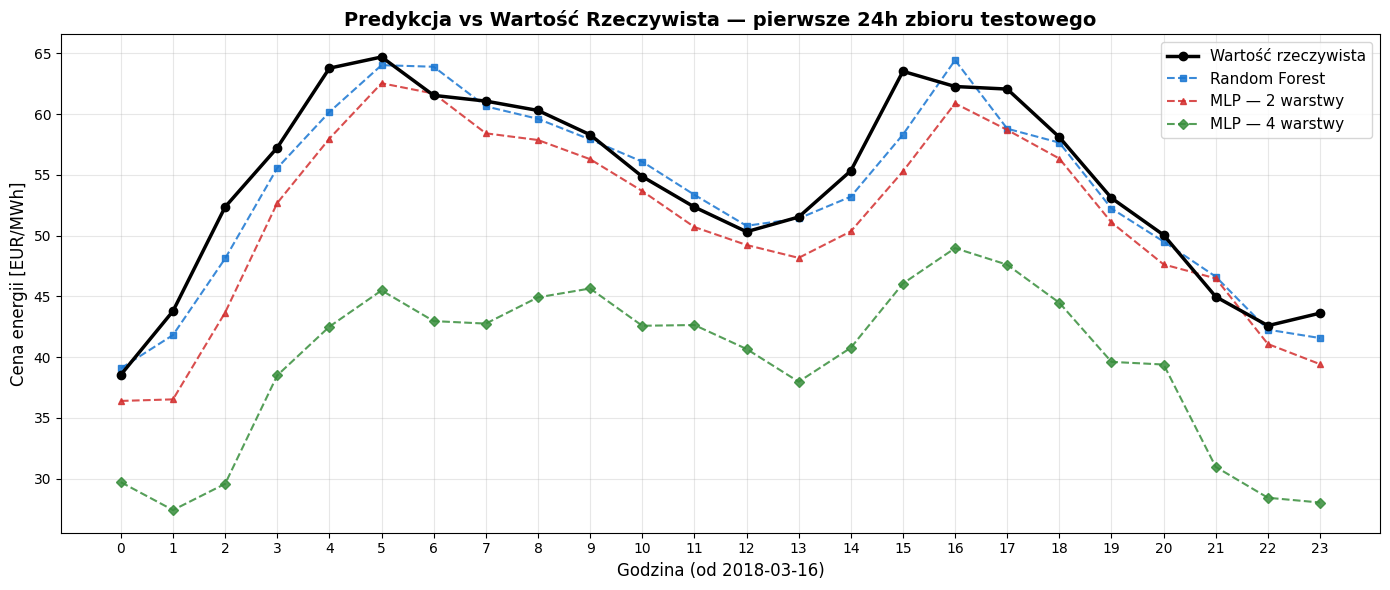

In [46]:
# Wykres predykcji dla pierwszych 24 godzin ze zbioru testowego
window = 24
hours = np.arange(window)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hours, y_test.values[:window], 'k-o',
        label='Wartość rzeczywista', linewidth=2.5, markersize=6, zorder=5)
ax.plot(hours, y_pred_rf[:window], '--s',
        label='Random Forest', linewidth=1.5, markersize=5,
        alpha=0.85, color='#1976D2')
ax.plot(hours, y_pred_mlp_a[:window], '--^',
        label='MLP — 2 warstwy', linewidth=1.5, markersize=5,
        alpha=0.85, color='#D32F2F')
ax.plot(hours, y_pred_mlp_b[:window], '--D',
        label='MLP — 4 warstwy', linewidth=1.5, markersize=5,
        alpha=0.85, color='#388E3C')

start_date = y_test.index[0].strftime('%Y-%m-%d')
ax.set_xlabel(f'Godzina (od {start_date})', fontsize=12)
ax.set_ylabel('Cena energii [EUR/MWh]', fontsize=12)
ax.set_title('Predykcja vs Wartość Rzeczywista — pierwsze 24h zbioru testowego',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(hours)

plt.tight_layout()
plt.show()

---
## 8. Wnioski

Na podstawie przeprowadzonej analizy i porównania trzech modeli predykcji ceny energii
można sformułować następujące wnioski:

**1. Inżynieria cech jest kluczowa**
- Cechy opóźnione (*lags*), szczególnie cena sprzed 1 godziny, okazały się jednymi z najważniejszych predyktorów
- Średnie kroczące pomagają uchwycić trend cenowy
- Cechy czasowe (godzina, dzień tygodnia) pozwalają modelom nauczyć się sezonowości dobowej i tygodniowej

**2. Random Forest jako solidny baseline**
- Prosty w konfiguracji i szybki w trenowaniu
- Daje dobre wyniki „out of the box" bez specjalnego dostrajania
- Pozwala łatwo interpretować, które cechy mają największy wpływ na predykcję

**3. Porównanie architektur MLP**
- Większa liczba warstw ukrytych nie zawsze oznacza lepsze wyniki — zależy to od złożoności problemu
- Kluczową rolę odgrywa regularyzacja (Dropout) i mechanizm Early Stopping
- Sieci neuronowe wymagają starannego doboru hiperparametrów i dłuższego czasu trenowania

**4. Wpływ danych pogodowych**
- Temperatura i warunki atmosferyczne mają pośredni wpływ na cenę energii (zużycie na ogrzewanie/chłodzenie)
- Prędkość wiatru wpływa na produkcję z farm wiatrowych, co z kolei wpływa na cenę

### Ograniczenia projektu
- Wykorzystano podstawową architekturę MLP — modele rekurencyjne (LSTM/GRU) mogłyby lepiej uchwycić zależności czasowe
- Brak systematycznej optymalizacji hiperparametrów (np. Grid Search, Random Search)
- Model wykorzystuje niektóre dane z bieżącego okresu (np. `total load actual`), co w praktyce nie byłoby dostępne w czasie rzeczywistym

### Możliwe kierunki rozwoju
- Zastosowanie modeli rekurencyjnych (LSTM/GRU) do lepszego modelowania sekwencji czasowych
- Optymalizacja hiperparametrów za pomocą walidacji krzyżowej
- Dodanie danych o planowanych wyłączeniach elektrowni lub imporcie/eksporcie energii
- Wykorzystanie wyłącznie danych dostępnych w momencie predykcji (prawdziwy scenariusz produkcyjny)